---
# EMITTANCE EXCHANGE INSERTION
---
https://cds.cern.ch/record/261067/files/p219.pdf


Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


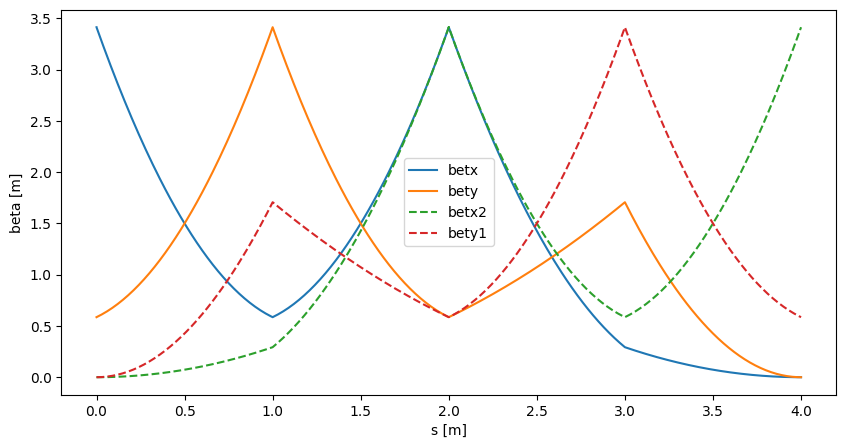

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import nafflib
import pytori as pt
import pytori.plotting as ptplt

import xtrack as xt
import xobjects as xo


# CELL parameters
#-----------------------
L       = 1                 #-- drift length
k       = np.sqrt(2)/L      #-- focusing strength
divs    = 100               #-- drift divisions (for visualization)
#-----------------------


# Expected twiss
#-----------------------
mu = 0.25
betx = L*k*(2/k + L) / np.sin(2*np.pi*mu)
bety = L*k*(2/k - L) / np.sin(2*np.pi*mu)
alfx = -L*k*(1+ L*k/2) / np.sin(2*np.pi*mu)
alfy =  L*k*(1- L*k/2) / np.sin(2*np.pi*mu)
twiss_init = xt.TwissInit(betx=betx, bety=bety, alfx=alfx, alfy=alfy)
ks = 1/np.sqrt(betx*bety) 
# ks = 0
#-----------------------

# ELEMENTS
#=========================================================================================
elements = {
            f'entry'        : xt.Marker(),
            f'SK1'          : xt.Multipole(knl=[0,0],ksl=[0,ks],length=0),
            f'QF.1'         : xt.Multipole(knl=[0, k],ksl=[0,0],length=0),
            **{f'O1.1.{i}'  : xt.Drift(length=L/divs) for i in range(divs)},
            f'QD.1'         : xt.Multipole(knl=[0,-k],ksl=[0,0],length=0),
            **{f'O2.1.{i}'  : xt.Drift(length=L/divs) for i in range(divs)},
            f'SK2'          : xt.Multipole(knl=[0,0],ksl=[0,ks],length=0),
            f'QF.2'         : xt.Multipole(knl=[0, k],ksl=[0,0],length=0),
            **{f'O1.2.{i}'  : xt.Drift(length=L/divs) for i in range(divs)},
            f'QD.2'         : xt.Multipole(knl=[0,-k],ksl=[0,0],length=0),
            **{f'O2.2.{i}'  : xt.Drift(length=L/divs) for i in range(divs)},
            f'SK3'          : xt.Multipole(knl=[0,0],ksl=[0,ks],length=0),
            }
#=========================================================================================

# BEAM & XSUITE LINE
#=========================================================================================
nrj             = 7000e9
particle_ref    = xt.Particles(p0c=nrj, q0=1, mass0=xt.PROTON_MASS_EV)
context         = xo.ContextCpu(omp_num_threads='auto')
#-----------------------------------------------------------------------------------------
line = xt.Line(elements=elements)
line.particle_ref = particle_ref
line.build_tracker(_context=context)
#=========================================================================================
line.freeze_longitudinal(True)
twiss = line.twiss4d(start =line.element_names[0],end=line.element_names[-1],init=twiss_init)
#=========================================================================================


plt.figure(figsize=(10,5))
plt.plot(twiss.s, twiss.betx, label='betx')
plt.plot(twiss.s, twiss.bety, label='bety')
plt.plot(twiss.s, twiss.betx2,'--', label='betx2')
plt.plot(twiss.s, twiss.bety1,'--', label='bety1')
plt.xlabel('s [m]')
plt.ylabel('beta [m]')
plt.legend()



### Projected area
We can track a matched torus the torus and see that the projected areas in the two planes are swapped

╭─────────────────────────────────────────────── Torus (FourierSeries) ────────────────────────────────────────────────╮
│                                                                                                                      │
│  ╭────────────────────────── x ──────────────────────────╮                                                           │
│  │                                                       │                                                           │
│  │   Index     Value                       Norm          │                                                           │
│  │   ( 1, 0)  -3.09228e-05 - 1.69122e-05j  3.52454e-05   │                                                           │
│  │   (-1, 0)  -1.69122e-05 - 1.69122e-05j  2.39175e-05   │                                                           │
│  │                                                       │                                                           │
│  ╰─────────────────────── terms=2 ───────────────────────╯                                                           │
│  ╭────────────────────────── y ──────────────────────────╮                                                           │
│  │                                                       │                                                           │
│  │   Index     Value                       Norm          │                                                           │
│  │   ( 0, 1)   1.19939e-05 + 3.13285e-06j  1.23963e-05   │                                                           │
│  │   ( 0,-1)   3.13285e-06 + 3.13285e-06j  4.43052e-06   │                                                           │
│  │                                                       │                                                           │
│  ╰─────────────────────── terms=2 ───────────────────────╯                                                           │
│                                                                                                                      │
╰─ dim=2, β₀=(1, 1, 1), (Ix,Iy)=(3.35e-10, 6.7e-11), max_order=None, max_terms=100, numerical_tol=None, backend='numpy─╯

╭─────────────────────────────────────────────── Torus (FourierSeries) ────────────────────────────────────────────────╮
│                                                                                                                      │
│  ╭────────────────────────── x ──────────────────────────╮                                                           │
│  │                                                       │                                                           │
│  │   Index     Value                       Norm          │                                                           │
│  │   ( 0, 1)   7.56338e-06 + 1.38291e-05j  1.57622e-05   │                                                           │
│  │   ( 0,-1)  -7.56338e-06 - 7.56338e-06j  1.06962e-05   │                                                           │
│  │   (-1, 0)  -2.87991e-19 - 2.37057e-19j  3.73008e-19   │                                                           │
│  │   ( 1, 0)   1.32137e-19 + 2.71534e-19j  3.01978e-19   │                                                           │
│  │                                                       │                                                           │
│  ╰─────────────────────── terms=4 ───────────────────────╯                                                           │
│  ╭────────────────────────── y ──────────────────────────╮                                                           │
│  │                                                       │                                                           │
│  │   Index     Value                       Norm          │                                                           │
│  │   ( 1, 0)   7.00527e-06 + 2.68192e-05j  2.77190e-05   │                                                           │
│  │   (-1, 0)   7.00527e-06 + 7.00527e-06j  9.90695e-06   │                                                           │
│  │   ( 0, 1)   1.10114e-20 + 9.59660e-21j  1.46064e-20   │                                                           │
│  │   ( 0,-1)  -0.00000e+00 - 4.32651e-21j  4.32651e-21   │                                                           │
│  │                                                       │                                                           │
│  ╰─────────────────────── terms=4 ───────────────────────╯                                                           │
│                                                                                                                      │
╰─ dim=2, β₀=(1, 1, 1), (Ix,Iy)=(3.35e-10, 6.7e-11), max_order=None, max_terms=100, numerical_tol=None, backend='numpy─╯

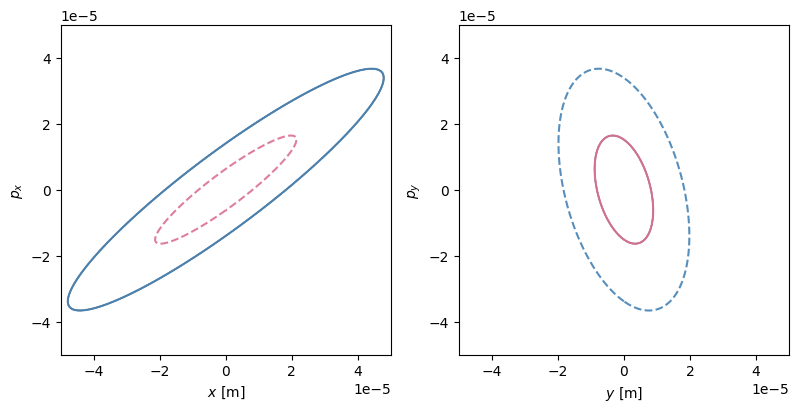

In [2]:
# Constructing matched torus from W-matrix (2D here)
x_sig  = 1
y_sig  = 1
nemitt_x = 5e-6
nemitt_y = 1e-6
torus0 = pt.Torus.linear_match(I=[(x_sig**2)/2,(y_sig**2)/2],
                               W_matrix=twiss.W_matrix[0],
                               nemitt_x=nemitt_x, 
                               nemitt_y=nemitt_y,
                               particle_on_co=twiss.particle_on_co)

# Tracking & plotting
Ixx = []
Ixy = []
Iyx = []
Iyy = []
torus = torus0.copy()
for ee,ee_name in zip(line.elements,line.element_names):
    if isinstance(ee,xt.Drift):
        torus = pt.transforms.drift(torus,ds=ee.length)
    elif isinstance(ee,xt.Multipole):
        torus = pt.transforms.multipole(torus,knl=ee.knl,ksl=ee.ksl)

    if ee_name == 'QF.2':
        torus_mid = torus.copy()
    Ixx.append(torus.Ixx())
    Ixy.append(torus.Ixy())
    Iyx.append(torus.Iyx())
    Iyy.append(torus.Iyy())
    # display(torus)
    
# Transformed torus
torus1 = torus.copy()
Ixx = np.array(Ixx)
Ixy = np.array(Ixy)
Iyx = np.array(Iyx)
Iyy = np.array(Iyy)

display(torus0)
display(torus1)


# Plotting
#--------------------------------------------------
x_color = 'steelblue'
y_color = 'palevioletred'

fig, axes = plt.subplots(1, 2, figsize=(8.1,4))

for torus,ls in zip([torus0, torus1],['-','--']):

    # TORUS SHADOW, plotting all possible angle values
    #=======================================================
    T_loop = np.linspace(0,2*np.pi,100)
    T_vals = np.linspace(0,2*np.pi,20)

    plt.sca(axes[0])
    for T0 in T_vals[:-1]:
        ptplt.loop(torus,proj='x',Tx=T_loop,Ty=T0,edgecolor='dimgrey',alpha=0.1,lw=1)

    plt.sca(axes[1])
    for T0 in T_vals[:-1]:
        ptplt.loop(torus,proj='y',Tx=T0,Ty=T_loop,edgecolor='dimgrey',alpha=0.1,lw=1)
    #=======================================================


    # Plotting a specific loop
    #=======================================================
    plt.sca(axes[0])
    # same as ptplt.xloop(torus,looping='x')
    ptplt.loop(torus,proj='x',looping='x',edgecolor=x_color,alpha=0.9,lw=1.5,ls=ls)
    ptplt.loop(torus,proj='x',looping='y',edgecolor=y_color,alpha=0.9,lw=1.5,ls=ls)

    plt.sca(axes[1])
    # same as ptplt.yloop(torus,looping='x')
    ptplt.loop(torus,proj='y',looping='x',edgecolor=x_color,alpha=0.9,lw=1.5,ls=ls)
    ptplt.loop(torus,proj='y',looping='y',edgecolor=y_color,alpha=0.9,lw=1.5,ls=ls)


for ax,plane in zip(axes,['x','y']):
    plt.sca(ax)
    plt.axis('equal')
    plt.gca().set_box_aspect(1) 
    plt.xlabel(rf'${plane}\ [\mathrm{{m}}]$');
    plt.ylabel(rf'$p_{plane}$');
    plt.xlim(-5e-5,5e-5)
    plt.ylim(-5e-5,5e-5)
plt.tight_layout()

## Action conservation
The total action is unchanged, but the contributions from each of the angle variables are swapped:

(5e-11, 3.6e-10)

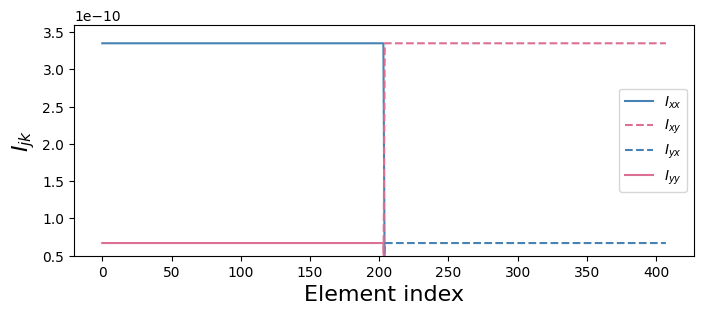

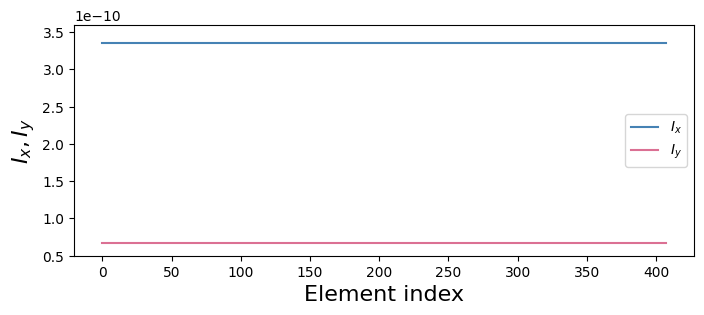

In [5]:
plt.figure(figsize=(8,3))
plt.plot(Ixx,color=x_color,ls='-',label='$I_{xx}$')
plt.plot(Ixy,color=y_color,ls='--',label='$I_{xy}$')
# plt.plot(Iyx,label='Iyx')
# plt.plot(Iyy,label='Iyy')
plt.xlabel('Element index')
plt.ylabel('Action invariants')
plt.legend()


plt.plot(Iyx,color=x_color,ls='--',label='$I_{yx}$')
plt.plot(Iyy,color=y_color,ls='-',label='$I_{yy}$')
# plt.plot(Iyx,label='Iyx')
# plt.plot(Iyy,label='Iyy')
plt.xlabel('Element index',fontsize=16)
plt.ylabel('$I_{jk}$',fontsize=16)
plt.legend()
plt.ylim(0.5e-10,3.6e-10)


plt.figure(figsize=(8,3))
plt.plot(Ixx + Ixy,color=x_color,ls='-',label='$I_{x}$')
plt.plot(Iyy + Iyx,color=y_color,ls='-',label='$I_{y}$')

plt.xlabel('Element index',fontsize=16)
plt.ylabel('$I_{x}, I_y$',fontsize=16)
plt.legend()
plt.ylim(0.5e-10,3.6e-10)

## Spectrum analysis: generalized optics
This exchange is purely an optics effect (i.e. machine property) and can be inferred from the $\Lambda_\pm = \begin{pmatrix}
        \lambda^\pm_{xx} & \lambda^\pm_{xy} \\
        \lambda^\pm_{yx} & \lambda^\pm_{yy} \\
    \end{pmatrix}$ matrices.

The horizontal motion, for example, follows:
$$x-ip_x = \sqrt{2I_x}(\lambda_{xx}^+ e^{i(2\pi Q_x)N} + \lambda_{xx}^- e^{-i(2\pi Q_x)N})+\sqrt{2I_y}(\lambda_{xy}^+ e^{i(2\pi Q_y)N} + \lambda_{xy}^- e^{-i(2\pi Q_y)N}) $$

where $\lambda_{jk}^\pm$ are optics terms which can be found (as a convenient approach) fromt the W-matrix. More details can be found in P. Bélanger's thesis.

As a result, one should conclude that the action (the single-particle emittance) is NOT exchanged, but that the optical functions are such that the projected areas in each planes are swapped. The dominant frequency in the spectrum (which should not be confused with the fundamental frequencies $(Q_x,Q_y)$) then corresponds to $\text{max}(\mathcal{F}(\nu)) \mapsto \nu = Q_y$ in the horizontal plane and $\nu = Q_x$ in the vertical plane at the exit of the insertion.


Text(0, 0.5, 'Coupled Optics Functions')

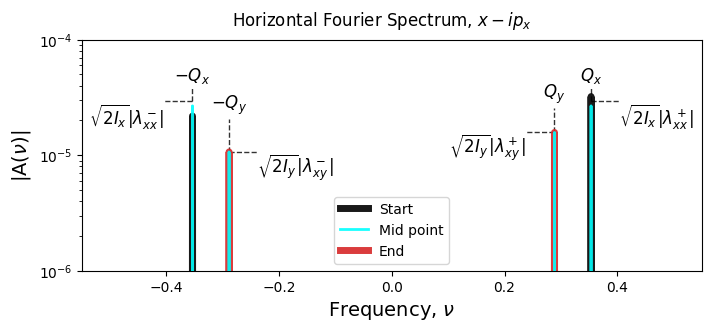

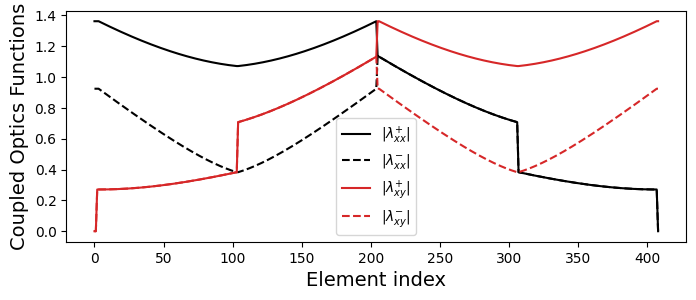

In [6]:
# Constructing matched torus from W-matrix (2D here)
x_sig  = 1
y_sig  = 1
nemitt_x = 5e-6
nemitt_y = 1e-6
torus0 = pt.Torus.linear_match(I=[(x_sig**2)/2,(y_sig**2)/2],
                               W_matrix=twiss.W_matrix[0],
                               nemitt_x=nemitt_x, 
                               nemitt_y=nemitt_y,
                               particle_on_co=twiss.particle_on_co)

# Tracking & plotting
torus = torus0.copy()
for ee,ee_name in zip(line.elements,line.element_names):
    if isinstance(ee,xt.Drift):
        torus = pt.transforms.drift(torus,ds=ee.length)
    elif isinstance(ee,xt.Multipole):
        torus = pt.transforms.multipole(torus,knl=ee.knl,ksl=ee.ksl)

    if ee_name == 'SK2':
        torus1 = torus.copy()
    
    
torus2 = torus.copy()


# Let's plot the corresponding fourier spectrum
num_turns = int(2e4)
#--------------
# Dummy sampling rates to distribute particles on the torus
fx  = 1/2/np.sqrt(2)
fy  = 1/2/np.sqrt(3)
# Angle variables for sampling points on the torus
T_N = {'Tx':2*np.pi*fx*np.arange(num_turns),
       'Ty':2*np.pi*fy*np.arange(num_turns)}
#--------------





# SPECTRUM
#------------------
nu        = np.linspace(-0.5,0.5,10000) 
t0_dffts  = nafflib.naff_dfft(nu, torus0.eval('x',**T_N), num_harmonics=1, window_order=4, window_type="hann")
t1_dffts  = nafflib.naff_dfft(nu, torus1.eval('x',**T_N), num_harmonics=1, window_order=4, window_type="hann")
t2_dffts  = nafflib.naff_dfft(nu, torus2.eval('x',**T_N), num_harmonics=1, window_order=4, window_type="hann")
#---------

plt.figure(figsize=(8,3))

plt.plot(nu, np.abs(t0_dffts[0])  ,'-' ,lw=5  ,color='k'   ,alpha=0.9,label='Start')
plt.plot(nu, np.abs(t1_dffts[0])  ,'-' ,lw=2  ,color='cyan',alpha=0.9,label='Mid point',zorder=10)
plt.plot(nu, np.abs(t2_dffts[0])  ,'-' ,lw=5  ,color='C3'  ,alpha=0.9,label='End')

plt.yscale('log')
plt.ylim(1e-6,10e-5)

hlength = 0.05
vlength = 1e-5
for nk,Ak in torus1.x.coeffs.items():
    
    nuk = np.dot(nk,[fx,fy])
    plane = 'x' if nk[0]!=0 else 'y'
    sign  = '-' if nuk<0 else ''
    xtag  = rf'${sign}Q_{plane}$'
    sign  = '-' if nuk<0 else '+'
    ytag  = rf'$\sqrt{{2I_{plane}}}|\lambda_{{x{plane}}}^{sign}|$'
    
    x0,y0 = nuk,np.abs(Ak)#/np.sqrt(2*Ix)
    # xlims = ax.get_xlim()
    # if (x0 < xlims[0]) or (x0 > xlims[1]):
    #     continue

    
    valign = 'top'
    offset = 0
    if nk == (0,-1):
        # valign = 'center'
        hlength = np.abs(hlength)
        halign = 'left'
    if nk == (0,1):
        # offset = - 0.4*hlength
        hlength = -np.abs(hlength)
        halign = 'right'
    if nk == (1,0):
        hlength = np.abs(hlength)
        halign = 'left'
    if nk == (-1,0):
        hlength = -np.abs(hlength)
        halign = 'right'
    plt.hlines(y0,x0,x0 + hlength ,color='k',ls='--',lw=1,alpha=0.8,zorder=-20)
    plt.text(x0 + offset + hlength*1.00,y0,ytag, fontsize=12,horizontalalignment=halign,verticalalignment=valign,color='k')

    plt.vlines(x0,y0,y0 + vlength ,color='k',ls='--',lw=1,alpha=0.8,zorder=-20)
    plt.text(x0 ,y0+ vlength*1.1,xtag, fontsize=12,horizontalalignment='center',verticalalignment='bottom',color='k')

plt.legend()
plt.suptitle('Horizontal Fourier Spectrum, $x - i p_x$')
plt.xlabel(r'Frequency, $\nu$', fontsize=14)
plt.ylabel(r'$|\mathrm{A}(\nu)|$', fontsize=14)




lp_xx = []
lm_xx = []
lp_xy = []
lm_xy = []
for W in twiss.W_matrix:
    lambda_plus, lambda_minus = pt.mathlib.W_to_lambda(W)
    lp_xx.append(lambda_plus[0,0])
    lm_xx.append(lambda_minus[0,0])
    lp_xy.append(lambda_plus[0,1])
    lm_xy.append(lambda_minus[0,1])

plt.figure(figsize=(8,3))
plt.plot(np.abs(lp_xx),'-' ,color='k',label=r'$|\lambda_{x x}^{+}|$')
plt.plot(np.abs(lm_xx),'--',color='k',label=r'$|\lambda_{x x}^{-}|$')
plt.plot(np.abs(lp_xy),'-',color='C3',label=r'$|\lambda_{x y}^{+}|$')
plt.plot(np.abs(lm_xy),'--',color='C3',label=r'$|\lambda_{x y}^{-}|$')
plt.legend()
plt.xlabel('Element index',fontsize=14)
plt.ylabel(r'Coupled Optics Functions',fontsize=14)

As a final remark, we can note that the generalized $\beta$-functions from Xsuite's twiss can be obtained in therms of the $\lambda_{jk}^\pm$ optics functions proposed here.

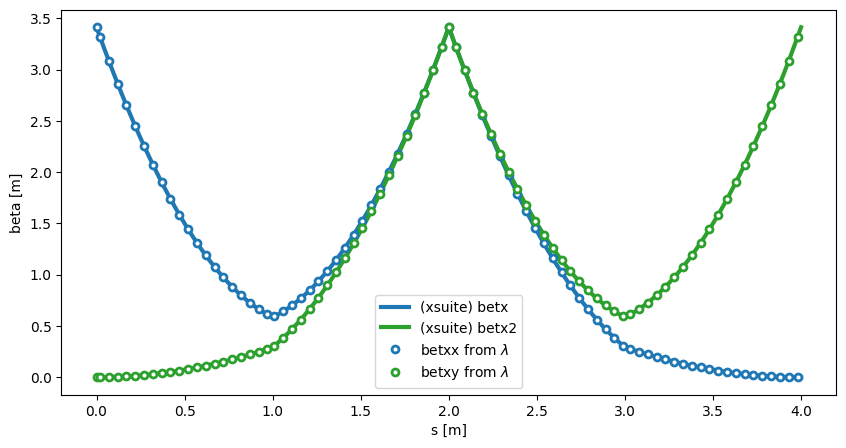

In [31]:
# Note: lambda_jk are uniteless and corresponds to some beta/beta0 ratio (where both are in meters). 
betxx = 1 * np.abs(np.array(lp_xx) + np.conjugate(lm_xx))**2
betxy = 1 * np.abs(np.array(lp_xy) + np.conjugate(lm_xy))**2

plt.figure(figsize=(10,5))
plt.plot(twiss.s, twiss.betx, color='C0',lw=3,label='(xsuite) betx')
plt.plot(twiss.s, twiss.betx2,color='C2',lw=3,label='(xsuite) betx2')

plt.plot(twiss.s[::5], betxx[::5],'o', color='C0',mfc='w',mec='C0',mew=2,ms=5,label=r'betxx from $\lambda$')
plt.plot(twiss.s[::5], betxy[::5],'o', color='C2',mfc='w',mec='C2',mew=2,ms=5,label=r'betxy from $\lambda$')


plt.xlabel('s [m]')
plt.ylabel('beta [m]')
plt.legend()
